In [195]:
import pandas as pd
import psycopg2

# PostgreSQL 연결
conn = psycopg2.connect(
    dbname="mydb",
    user="user",
    password="pass",
    host="my_postgres",
    port="5432"
)

# Pandas로 데이터 불러오기
df = pd.read_sql(
    "SELECT * FROM recipe_reviews_and_user_feedback_dataset", conn)
print(df.head())

conn.close()


   Column1  recipe_number  recipe_code         recipe_name  \
0        0              1        14299  Creamy White Chili   
1        1              1        14299  Creamy White Chili   
2        2              1        14299  Creamy White Chili   
3        3              1        14299  Creamy White Chili   
4        4              1        14299  Creamy White Chili   

                                        comment_id         user_id  \
0  sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM  u_9iFLIhMa8QaG   
1  sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY  u_Lu6p25tmE77j   
2  sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP  u_s0LwgpZ8Jsqq   
3  sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC  u_fqrybAdYjgjG   
4  sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI  u_XXWKwVhKZD69   

    user_name  user_reputation  created_at  reply_count  thumbs_up  \
0     Jeri326                1  1665619889            0          0   
1     Mark467               50  1665277687            0          7

/tmp/ipykernel_330/3589062472.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


In [196]:
df.dtypes

Column1             int64
recipe_number       int64
recipe_code         int64
recipe_name        object
comment_id         object
user_id            object
user_name          object
user_reputation     int64
created_at          int64
reply_count         int64
thumbs_up           int64
thumbs_down         int64
stars               int64
best_score          int64
text               object
dtype: object

In [197]:
df.head()

,Column1,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ..."
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee..."
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...


In [198]:
# 타임스탬프를 datetime으로 변환 (UTC 기준)
df['datetime_utc'] = pd.to_datetime(df['created_at'], unit='s', utc=True)

# UTC를 PST로 변환
df['datetime_pst'] = df['datetime_utc'].dt.tz_convert('US/Pacific')


In [199]:
df.head()

,Column1,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,thumbs_up,thumbs_down,stars,best_score,text,datetime_utc,datetime_pst
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,0,0,5,527,"I tweaked it a little, removed onions because ...",2022-10-13 00:11:29+00:00,2022-10-12 17:11:29-07:00
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,7,0,5,724,Bush used to have a white chili bean and it ma...,2022-10-09 01:08:07+00:00,2022-10-08 18:08:07-07:00
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,3,0,5,710,I have a very complicated white chicken chili ...,2022-09-28 22:35:57+00:00,2022-09-28 15:35:57-07:00
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,2,0,0,581,"In your introduction, you mentioned cream chee...",2022-08-29 15:43:28+00:00,2022-08-29 08:43:28-07:00
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,7,0,0,820,Wonderful! I made this for a &#34;Chili/Stew&#...,2022-10-04 20:03:43+00:00,2022-10-04 13:03:43-07:00


In [200]:
print(df.recipe_code.nunique())
print(df.user_id.nunique())


100
13812


In [201]:
print(df.created_at.nunique())

2695


In [202]:
df.columns

Index(['Column1', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id',
       'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count',
       'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text',
       'datetime_utc', 'datetime_pst'],
      dtype='object')

In [203]:
len(df[['user_id', 'user_reputation']].drop_duplicates())

13894

In [204]:
tmp = df.groupby(['user_id'])[['created_at']].count().reset_index().rename(columns = {'created_at' : 'freq_reaction'})
df = pd.merge(df, tmp, how = 'left', on = ['user_id']) # add feature that indicate the frequency of comment
df['adj_reput'] = df['user_reputation'] / df['freq_reaction'] # add featrue that indicate reputation comparing comment frequency

In [205]:
df.columns

Index(['Column1', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id',
       'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count',
       'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text',
       'datetime_utc', 'datetime_pst', 'freq_reaction', 'adj_reput'],
      dtype='object')

In [206]:
df[['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'freq_reaction', 'adj_reput']].describe()

,user_reputation,reply_count,thumbs_up,thumbs_down,stars,best_score,freq_reaction,adj_reput
count,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000,18182.000000
mean,2.159608,0.014630,1.089264,0.549335,4.288802,153.162138,2.368496,1.157567
std,10.014666,0.137974,4.201004,3.470124,1.544786,141.075316,3.198295,3.902285
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,5.000000,100.000000,1.000000,0.500000
50%,1.000000,0.000000,0.000000,0.000000,5.000000,100.000000,1.000000,1.000000
75%,1.000000,0.000000,0.000000,0.000000,5.000000,100.000000,2.000000,1.000000
max,520.000000,3.000000,106.000000,126.000000,5.000000,946.000000,25.000000,173.333333


In [207]:
df[['user_reputation', 'reply_count', 'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'freq_reaction', 'adj_reput']].corr()


,user_reputation,reply_count,thumbs_up,thumbs_down,stars,best_score,freq_reaction,adj_reput
user_reputation,1.000000,0.010610,0.057863,0.022890,0.015554,0.137899,0.139781,0.882580
reply_count,0.010610,1.000000,0.208788,0.327620,-0.119693,0.201306,-0.032410,0.036246
thumbs_up,0.057863,0.208788,1.000000,0.373251,-0.050884,0.684837,-0.057807,0.100522
thumbs_down,0.022890,0.327620,0.373251,1.000000,-0.142555,0.215401,-0.043436,0.047460
stars,0.015554,-0.119693,-0.050884,-0.142555,1.000000,-0.034263,0.079119,-0.001024
best_score,0.137899,0.201306,0.684837,0.215401,-0.034263,1.000000,-0.069434,0.197252
freq_reaction,0.139781,-0.032410,-0.057807,-0.043436,0.079119,-0.069434,1.000000,-0.046641
adj_reput,0.882580,0.036246,0.100522,0.047460,-0.001024,0.197252,-0.046641,1.000000


In [208]:
# To add effect of indirect opinion, I generated this feature.
df['like_ratio'] = df.thumbs_up / (df.thumbs_up + df.thumbs_down +1)


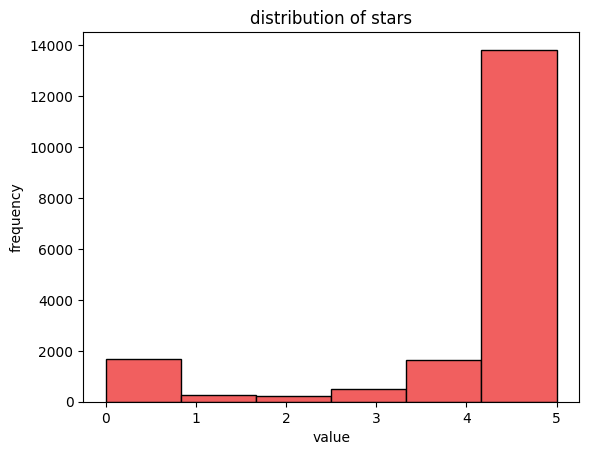

In [209]:
import matplotlib.pyplot as plt
import numpy as np

# draw histogram
plt.hist(df.stars, bins=6, color='#F15F5F', edgecolor='black')
plt.title('distribution of stars')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()


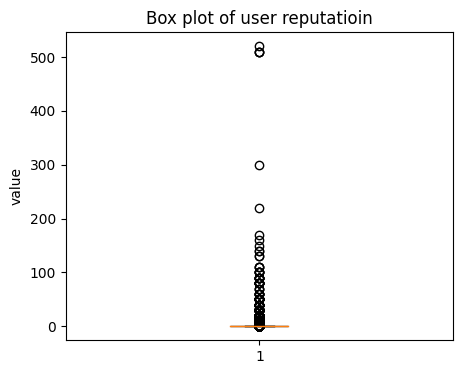

In [210]:
plt.figure(figsize=(5, 4))  # 그래프 크기 조정
plt.boxplot(df.user_reputation, patch_artist=True, boxprops=dict(facecolor='#F29661'))
plt.title('Box plot of user reputatioin')
plt.ylabel('value')
plt.show()


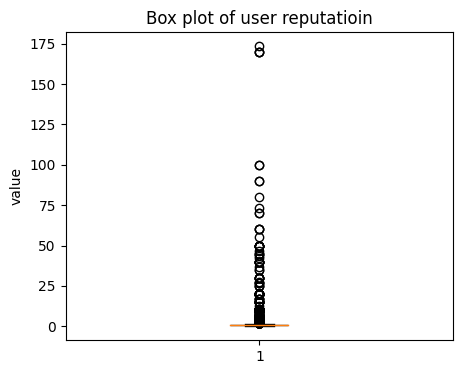

In [211]:
plt.figure(figsize=(5, 4))  # 그래프 크기 조정
plt.boxplot(df.adj_reput, patch_artist=True,
            boxprops=dict(facecolor='#F29661'))
plt.title('Box plot of user reputatioin')
plt.ylabel('value')
plt.show()


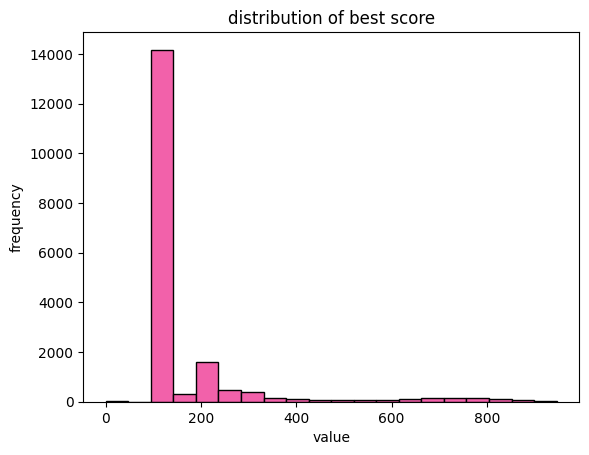

In [212]:
plt.hist(df.best_score, bins=20, color='#F261AA', edgecolor='black')
plt.title('distribution of best score')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()


In [213]:
reci = df.groupby('recipe_number').agg({
    'created_at': 'count',   
    'stars': 'mean',
    'best_score' : ('max', 'min')   
}).reset_index()



In [214]:
reci['diff_best_score'] = reci[('best_score','max')] - reci[('best_score','min')]
reci['diff_ratio'] = reci['diff_best_score'] / reci[('best_score','max')]

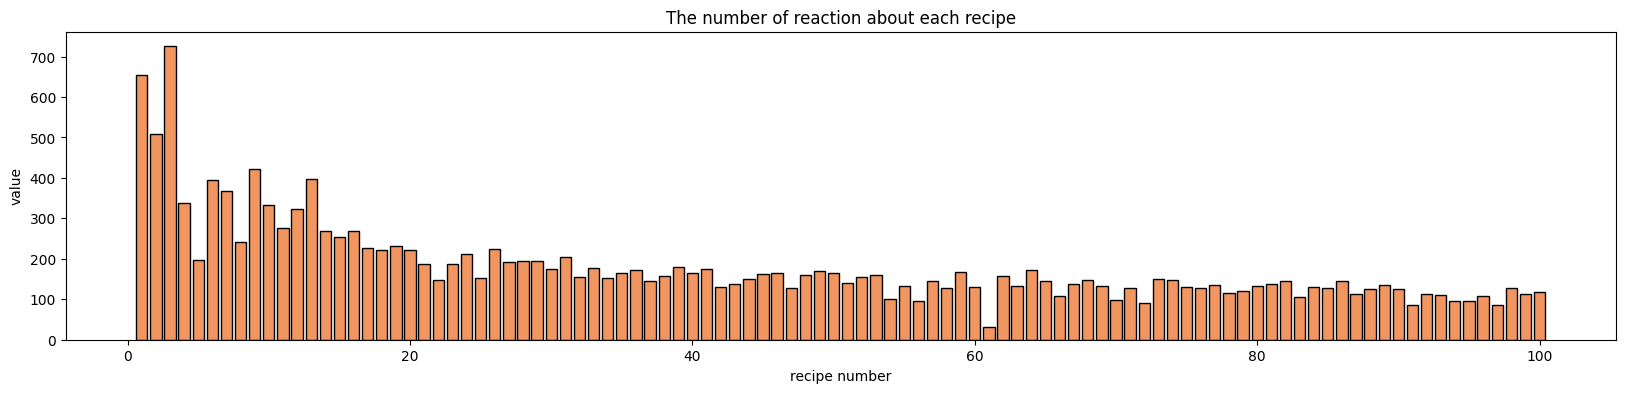

In [215]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci.recipe_number, reci[(('created_at', 'count'))],
        color='#F29661', edgecolor='black')
plt.title('The number of reaction about each recipe')
plt.xlabel('recipe number')
plt.ylabel('value')
plt.show()


In [251]:
reci

recipe_number created_at     stars best_score      diff_best_score  \
                      count      mean        max  min                   
0              1        654  4.452599        891  100             791   
1              2        509  4.587426        825    0             825   
2              3        725  4.576552        928   16             912   
3              4        338  4.526627        905    4             901   
4              5        197  4.461929        524  100             424   
..           ...        ...       ...        ...  ...             ...   
95            96        109  4.440367        731  100             631   
96            97         86  3.976744        762  100             662   
97            98        128  4.390625        887  100             787   
98            99        112  4.258929        758  100             658   
99           100        119  4.369748        889  100             789   

   diff_ratio  
               
0    0.887767  
1    1.000000  
2    0.982759  
3    0.995580  
4    0.809160  
..        ...  
95   0.863201  
96   0.868766  
97   0.887260  
98   0.868074  
99   0.887514  

[100 rows x 7 columns]

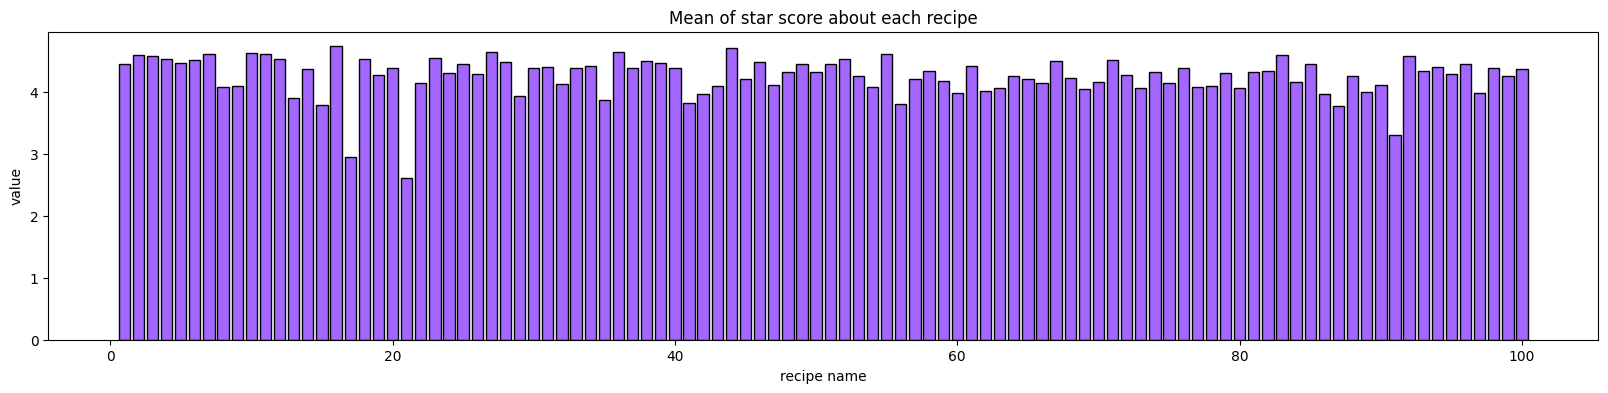

In [252]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci.recipe_number, reci[("stars", "mean")],
        color='#A366FF', edgecolor='black')
plt.title('Mean of star score about each recipe')
plt.xlabel('recipe name')
plt.ylabel('value')
plt.show()


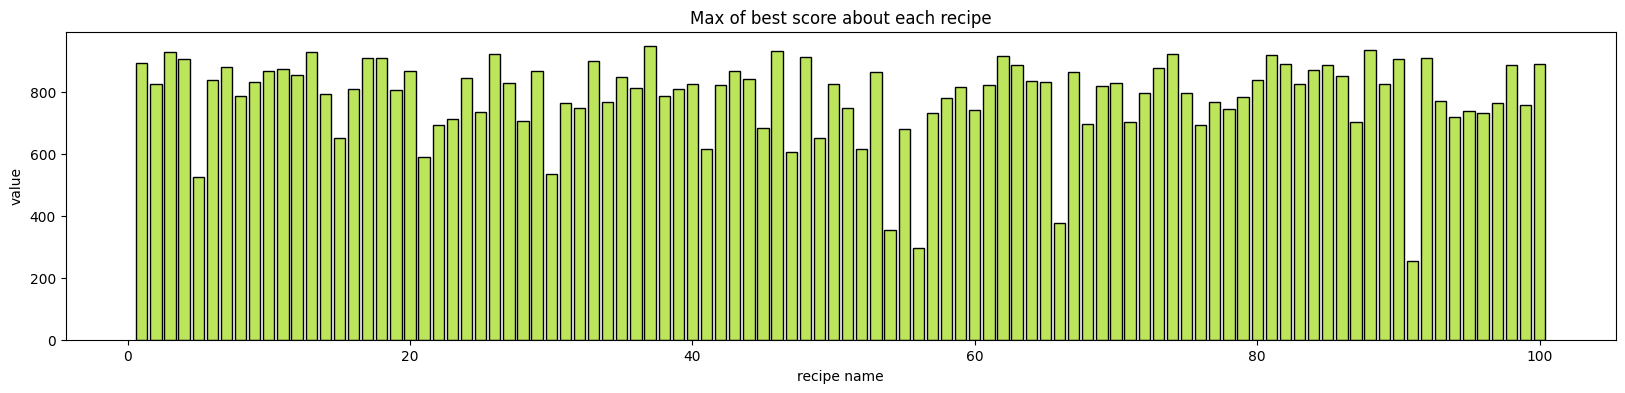

In [217]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci.recipe_number, reci[('best_score', 'max')],
        color='#BCE55C', edgecolor='black')
plt.title('Max of best score about each recipe')
plt.xlabel('recipe name')
plt.ylabel('value')
plt.show()


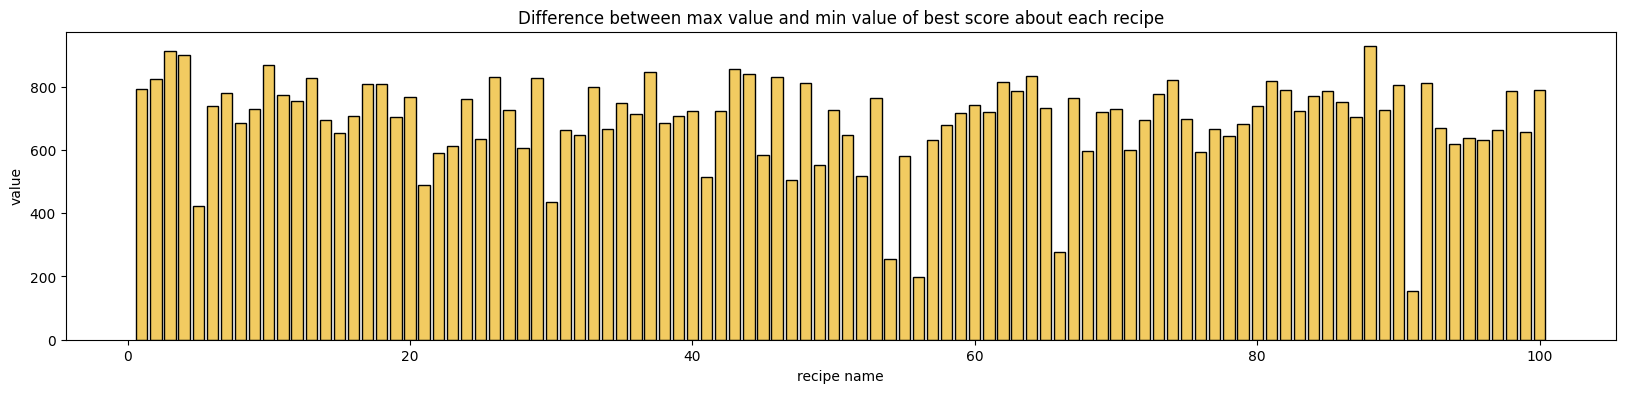

In [218]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci.recipe_number, reci.diff_best_score,
        color='#F2CB61', edgecolor='black')
plt.title('Difference between max value and min value of best score about each recipe')
plt.xlabel('recipe name')
plt.ylabel('value')
plt.show()


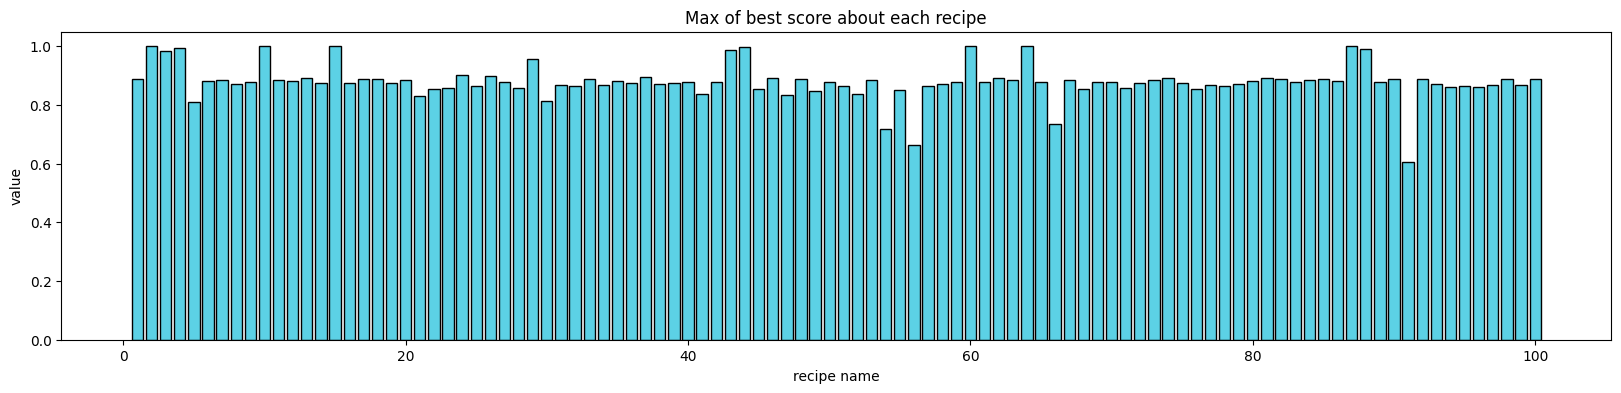

In [219]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci.recipe_number, reci.diff_ratio,
        color='#5CD1E5', edgecolor='black')
plt.title('Max of best score about each recipe')
plt.xlabel('recipe name')
plt.ylabel('value')
plt.show()


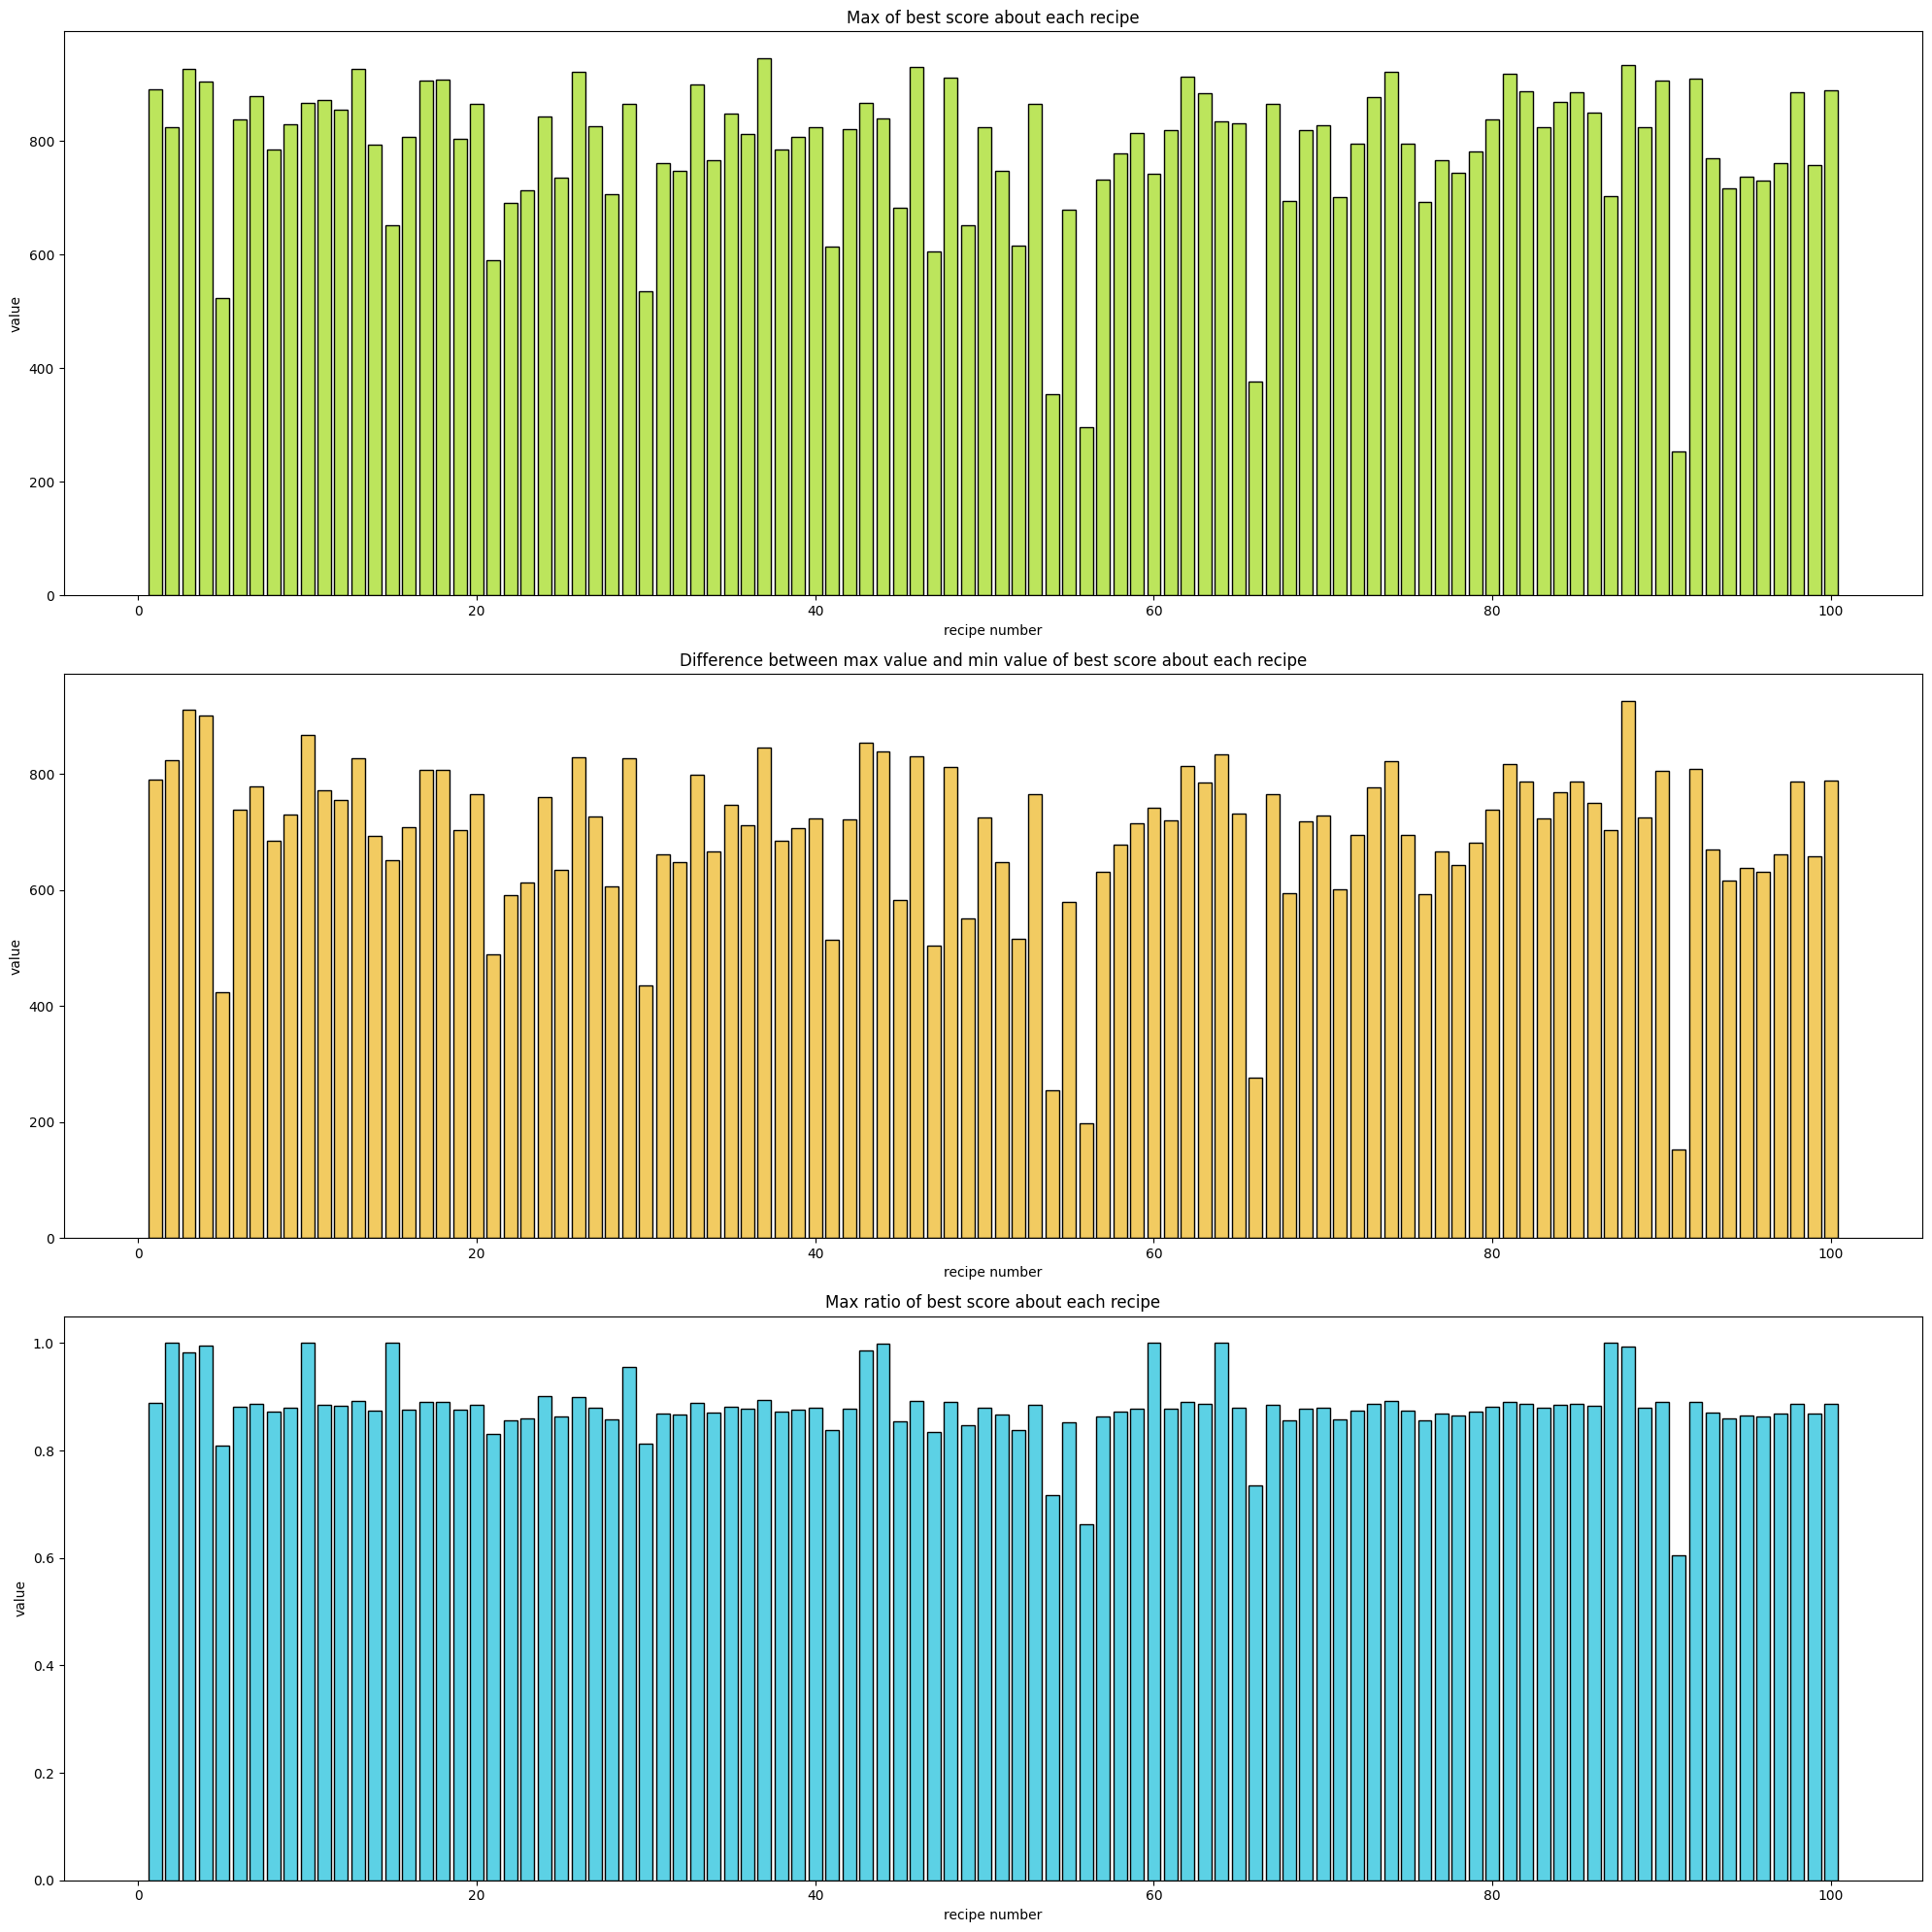

In [220]:
import matplotlib.pyplot as plt

# # 데이터가 일치하는지 확인하기
# print(len(reci.recipe_number), len(reci.best_score),
#       len(reci.diff_best_score), len(reci.diff_ratio))

# 그래프 그리기
ig, axs = plt.subplots(3, 1, figsize=(20, 20))

# 첫 번째 그래프
axs[0].bar(reci.recipe_number, reci[('best_score', 'max')],
           color='#BCE55C', edgecolor='black')
axs[0].set_title('Max of best score about each recipe')
axs[0].set_xlabel('recipe number')
axs[0].set_ylabel('value')

# 두 번째 그래프
axs[1].bar(reci.recipe_number, reci.diff_best_score,
           color='#F2CB61', edgecolor='black')
axs[1].set_title(
    'Difference between max value and min value of best score about each recipe')
axs[1].set_xlabel('recipe number')
axs[1].set_ylabel('value')

# 세 번째 그래프
axs[2].bar(reci.recipe_number, reci.diff_ratio,
           color='#5CD1E5', edgecolor='black')
axs[2].set_title('Max ratio of best score about each recipe')
axs[2].set_xlabel('recipe number')
axs[2].set_ylabel('value')

# 그래프 간격 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()


In [221]:
df.columns

Index(['Column1', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id',
       'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count',
       'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text',
       'datetime_utc', 'datetime_pst', 'freq_reaction', 'adj_reput',
       'like_ratio'],
      dtype='object')

In [222]:
df[['reply_count',
    'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'freq_reaction', 'adj_reput', 'like_ratio']].corr()


,reply_count,thumbs_up,thumbs_down,stars,best_score,freq_reaction,adj_reput,like_ratio
reply_count,1.000000,0.208788,0.327620,-0.119693,0.201306,-0.032410,0.036246,0.122213
thumbs_up,0.208788,1.000000,0.373251,-0.050884,0.684837,-0.057807,0.100522,0.587201
thumbs_down,0.327620,0.373251,1.000000,-0.142555,0.215401,-0.043436,0.047460,0.127486
stars,-0.119693,-0.050884,-0.142555,1.000000,-0.034263,0.079119,-0.001024,-0.005995
best_score,0.201306,0.684837,0.215401,-0.034263,1.000000,-0.069434,0.197252,0.771521
freq_reaction,-0.032410,-0.057807,-0.043436,0.079119,-0.069434,1.000000,-0.046641,-0.043951
adj_reput,0.036246,0.100522,0.047460,-0.001024,0.197252,-0.046641,1.000000,0.125528
like_ratio,0.122213,0.587201,0.127486,-0.005995,0.771521,-0.043951,0.125528,1.000000


In [223]:
# 새 변수 추가 stars (30%) + best_score(min-max 스케일링 후 * 5) (10%) + like_ratio (min-max 스케일링 후 * 5) (10%)

In [224]:
def minmaxscaling(col):
    min_val = col.min()
    max_val = col.max()
    result = []
    for c in col:
        val = (c-min_val) / (max_val-min_val) * 5
        result.append(val)
    return result

In [225]:
new_best_score = minmaxscaling(df.best_score)
new_like_ratio = minmaxscaling(df.like_ratio)

In [226]:
df['new_best_score'] = new_best_score
df['new_like_ratio'] = new_like_ratio

In [227]:
df['agg_rating'] = df.stars*(3/5) + df.new_best_score*(1/5) + df.new_like_ratio*(1/5)

In [228]:
df

,Column1,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,...,best_score,text,datetime_utc,datetime_pst,freq_reaction,adj_reput,like_ratio,new_best_score,new_like_ratio,agg_rating
0,0,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2G3aneMRgRMZwXqIHmSdXSG1hEM,u_9iFLIhMa8QaG,Jeri326,1,1665619889,0,...,527,"I tweaked it a little, removed onions because ...",2022-10-13 00:11:29+00:00,2022-10-12 17:11:29-07:00,1,1.000000,0.000000,2.785412,0.000000,3.557082
1,1,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FsPC83HtzCsQAtOxlbL6RcaPbY,u_Lu6p25tmE77j,Mark467,50,1665277687,0,...,724,Bush used to have a white chili bean and it ma...,2022-10-09 01:08:07+00:00,2022-10-08 18:08:07-07:00,1,50.000000,0.875000,3.826638,4.479167,4.661161
2,2,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2FPrSGyTv7PQkZq37j92r9mYGkP,u_s0LwgpZ8Jsqq,Barbara566,10,1664404557,0,...,710,I have a very complicated white chicken chili ...,2022-09-28 22:35:57+00:00,2022-09-28 15:35:57-07:00,1,10.000000,0.750000,3.752643,3.839286,4.518386
3,3,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DzdSIgV9qNiuBaLoZ7JQaartoC,u_fqrybAdYjgjG,jeansch123,1,1661787808,2,...,581,"In your introduction, you mentioned cream chee...",2022-08-29 15:43:28+00:00,2022-08-29 08:43:28-07:00,2,0.500000,0.666667,3.070825,3.412698,1.296705
4,4,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_2DtZJuRQYeTFwXBoZRfRhBPEXjI,u_XXWKwVhKZD69,camper77,10,1664913823,1,...,820,Wonderful! I made this for a &#34;Chili/Stew&#...,2022-10-04 20:03:43+00:00,2022-10-04 13:03:43-07:00,1,10.000000,0.875000,4.334038,4.479167,1.762641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18177,114,100,82745,Mamaw Emily’s Strawberry Cake,sp_aUSaElGf_82745_c_331352,u_1oKblS4ULpTAACUTILo0QlO5mrN,WhittierCA,1,1622717977,0,...,100,This Strawberry Cake has been a family favorit...,2021-06-03 10:59:37+00:00,2021-06-03 03:59:37-07:00,1,1.000000,0.000000,0.528541,0.000000,3.105708
18178,115,100,82745,Mamaw Emily’s Strawberry Cake,sp_aUSaElGf_82745_c_204836,u_1oKY7CKLaFQpI3cBCVaxHXAEGbt,susieswan,1,1613036720,0,...,100,<p>I received endless compliments on this cake...,2021-02-11 09:45:20+00:00,2021-02-11 01:45:20-08:00,1,1.000000,0.000000,0.528541,0.000000,3.105708
18179,116,100,82745,Mamaw Emily’s Strawberry Cake,sp_aUSaElGf_82745_c_301178,u_1oKXBAuHbMDi9nnriVAbJoPqpeQ,blajr,1,1622717844,0,...,100,This cake was delicious and so moist! I didn&#...,2021-06-03 10:57:24+00:00,2021-06-03 03:57:24-07:00,3,0.333333,0.000000,0.528541,0.000000,3.105708
18180,117,100,82745,Mamaw Emily’s Strawberry Cake,sp_aUSaElGf_82745_c_180512,u_1oKVbnueXfnlmYWuYH8xJ0mFxNQ,cafritz,1,1622717233,0,...,100,I just made this too. It is wonderful. As fo...,2021-06-03 10:47:13+00:00,2021-06-03 03:47:13-07:00,1,1.000000,0.000000,0.528541,0.000000,3.105708


In [229]:
tmp1 = df.groupby(['recipe_number'])[['agg_rating']].mean().reset_index()

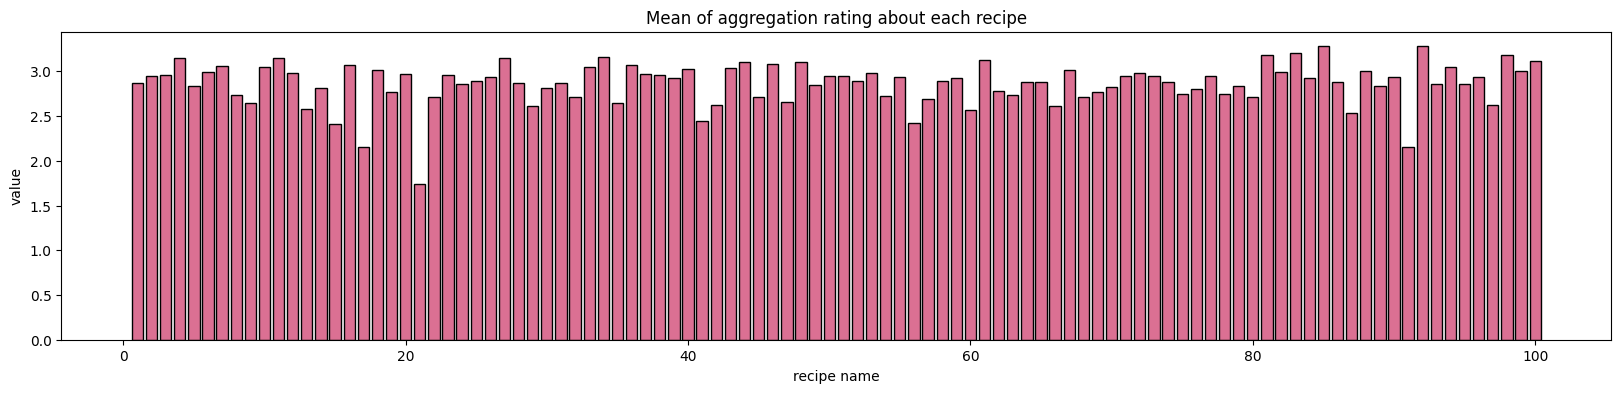

In [230]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(tmp1.recipe_number, tmp1.agg_rating,
        color='#db7093', edgecolor='black')
plt.title(
    'Mean of aggregation rating about each recipe')
plt.xlabel('recipe name')
plt.ylabel('value')
plt.show()


In [231]:
import os
os.getcwd()

'/root/workplace/profile'

In [232]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials

# ✅ 1. Google API 접근 권한 설정
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name(
    "solid-space-282708-8fba24fa09bf.json", scope)

# ✅ 2. 구글 시트 접근
client = gspread.authorize(creds)

# ✅ 3. 스프레드시트 열기 (URL의 key or 이름 사용)
spreadsheet = client.open("recipe_feature")

# ✅ 4. 워크시트 선택 (첫 번째 워크시트 가져오기)
sheet = spreadsheet.sheet1

# ✅ 5. 데이터 읽기
data = sheet.get_all_records()
print("💾 현재 데이터:", data)

# ✅ 6. 데이터 쓰기 (A1 셀에 값 입력)
# sheet.update_acell('A1', 'Hello from Docker!')

# ✅ 7. 새 행 추가
# sheet.append_row(['Python', 'Docker', 'Google Sheet'])

💾 현재 데이터: [{'recipe_name': 'Creamy White Chili', 'recipe_code': 14299, 'food_category': 'Soup/Chili', 'feature': '#creamy, #white, #chili, #hearty'}, {'recipe_name': 'Best Ever Banana Bread', 'recipe_code': 3309, 'food_category': 'Bread/Bakery', 'feature': '#banana, #bread, #classic, #homemade'}, {'recipe_name': 'Cheeseburger Soup', 'recipe_code': 2832, 'food_category': 'Soup', 'feature': '#cheeseburger, #soup, #hearty, #savory'}, {'recipe_name': 'Enchilada Casser-Ole!', 'recipe_code': 42083, 'food_category': 'Casserole/Mexican', 'feature': '#enchilada, #casserole, #Mexican, #spicy'}, {'recipe_name': 'Flavorful Chicken Fajitas', 'recipe_code': 12540, 'food_category': 'Tex-Mex/Chicken', 'feature': '#chicken, #fajitas, #flavorful, #sizzling'}, {'recipe_name': 'Amish Breakfast Casserole', 'recipe_code': 17826, 'food_category': 'Breakfast/Casserole', 'feature': '#breakfast, #casserole, #Amish, #hearty'}, {'recipe_name': 'Cauliflower Soup', 'recipe_code': 19731, 'food_category': 'Soup/Veget

In [233]:
recipe = pd.DataFrame(data)

In [234]:
recipe.food_category.nunique()

42

In [235]:
df = pd.merge(df, recipe[['recipe_code', 'food_category', 'feature']], how = 'left', on = ['recipe_code'])

In [236]:
df.columns

Index(['Column1', 'recipe_number', 'recipe_code', 'recipe_name', 'comment_id',
       'user_id', 'user_name', 'user_reputation', 'created_at', 'reply_count',
       'thumbs_up', 'thumbs_down', 'stars', 'best_score', 'text',
       'datetime_utc', 'datetime_pst', 'freq_reaction', 'adj_reput',
       'like_ratio', 'new_best_score', 'new_like_ratio', 'agg_rating',
       'food_category', 'feature'],
      dtype='object')

In [237]:
reci2 = df.groupby('food_category').agg({
    'created_at': 'count',
    'stars': 'mean',
    'best_score': ('max', 'min'),
    'agg_rating' : 'mean'
}).reset_index()


In [238]:
reci2['diff_score'] = reci2[('best_score', 'max')] - reci2[('best_score', 'min')]
reci2['diff_ratio'] = reci2['diff_score'] / reci2[('best_score','max')]

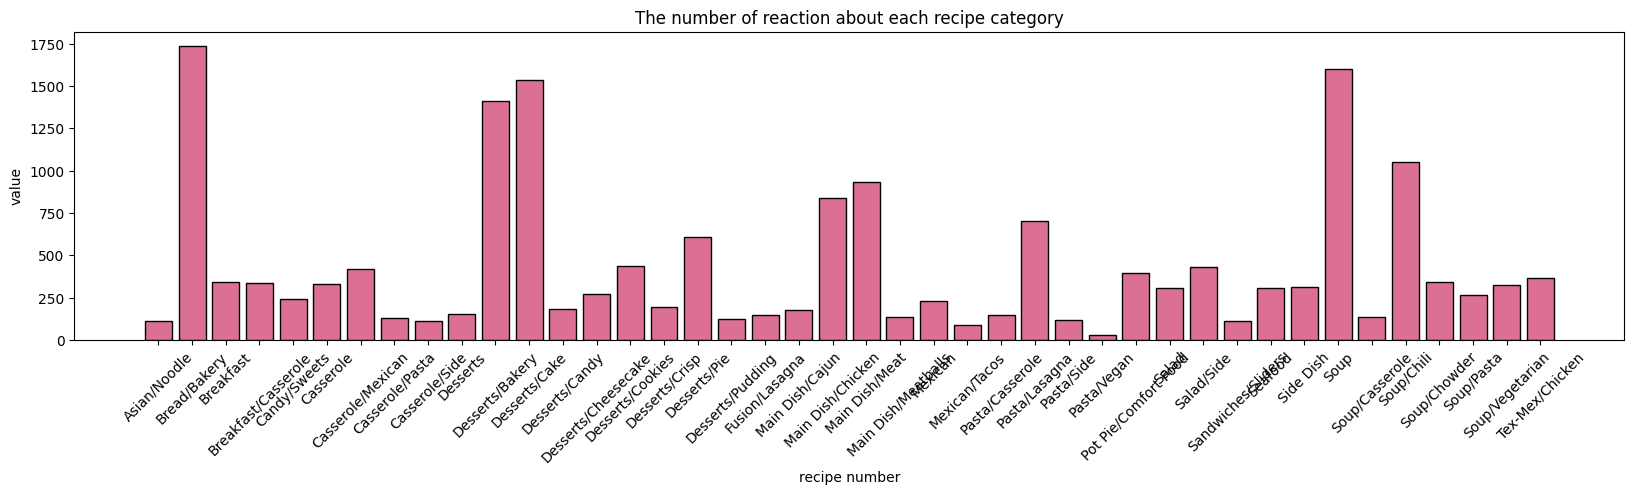

In [239]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci2.food_category, reci2[(('created_at', 'count'))],
        color='#DB7093', edgecolor='black')
plt.xticks(rotation=45)
plt.title('The number of reaction about each recipe category')
plt.xlabel('recipe number')
plt.ylabel('value')
plt.show()


In [240]:
# Bread/Bakery, Desserts/Bakery, Desserts/Cake, Soup, Soup/Chili 

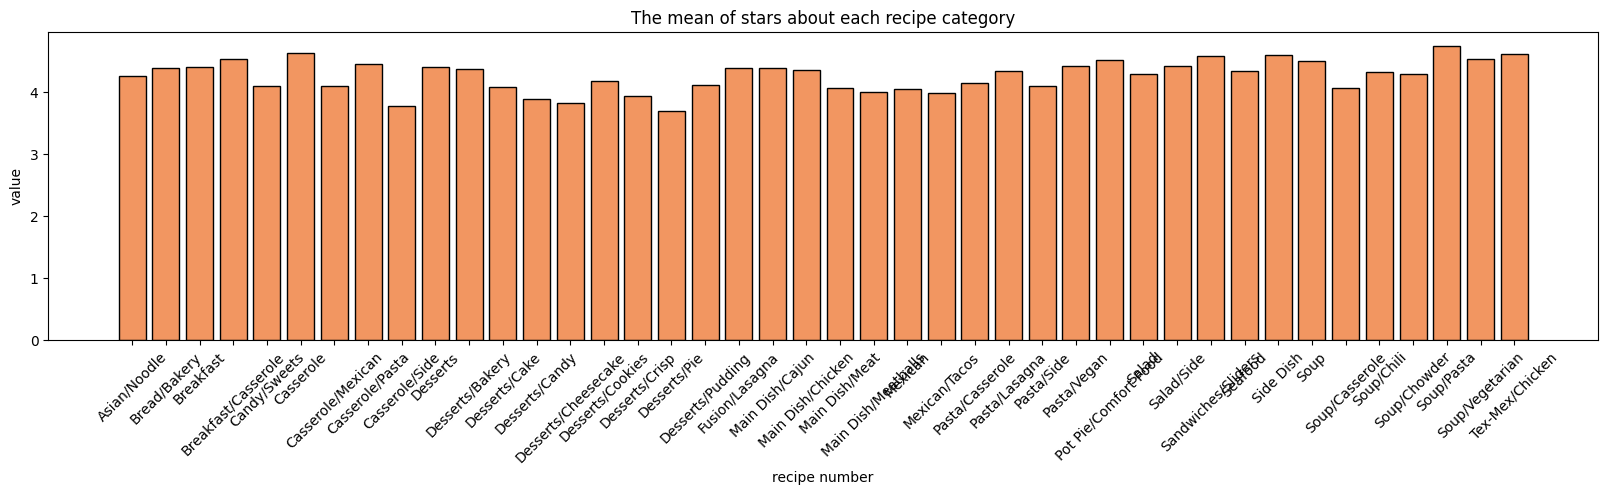

In [241]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci2.food_category, reci2[(('stars', 'mean'))],
        color='#F29661', edgecolor='black')
plt.xticks(rotation=45)
plt.title('The mean of stars about each recipe category')
plt.xlabel('recipe number')
plt.ylabel('value')
plt.show()


/tmp/ipykernel_330/3043492854.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[0].set_xticklabels(reci2.food_category, rotation=45)
/tmp/ipykernel_330/3043492854.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[1].set_xticklabels(reci2.food_category, rotation=45)
/tmp/ipykernel_330/3043492854.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs[2].set_xticklabels(reci2.food_category, rotation=45)


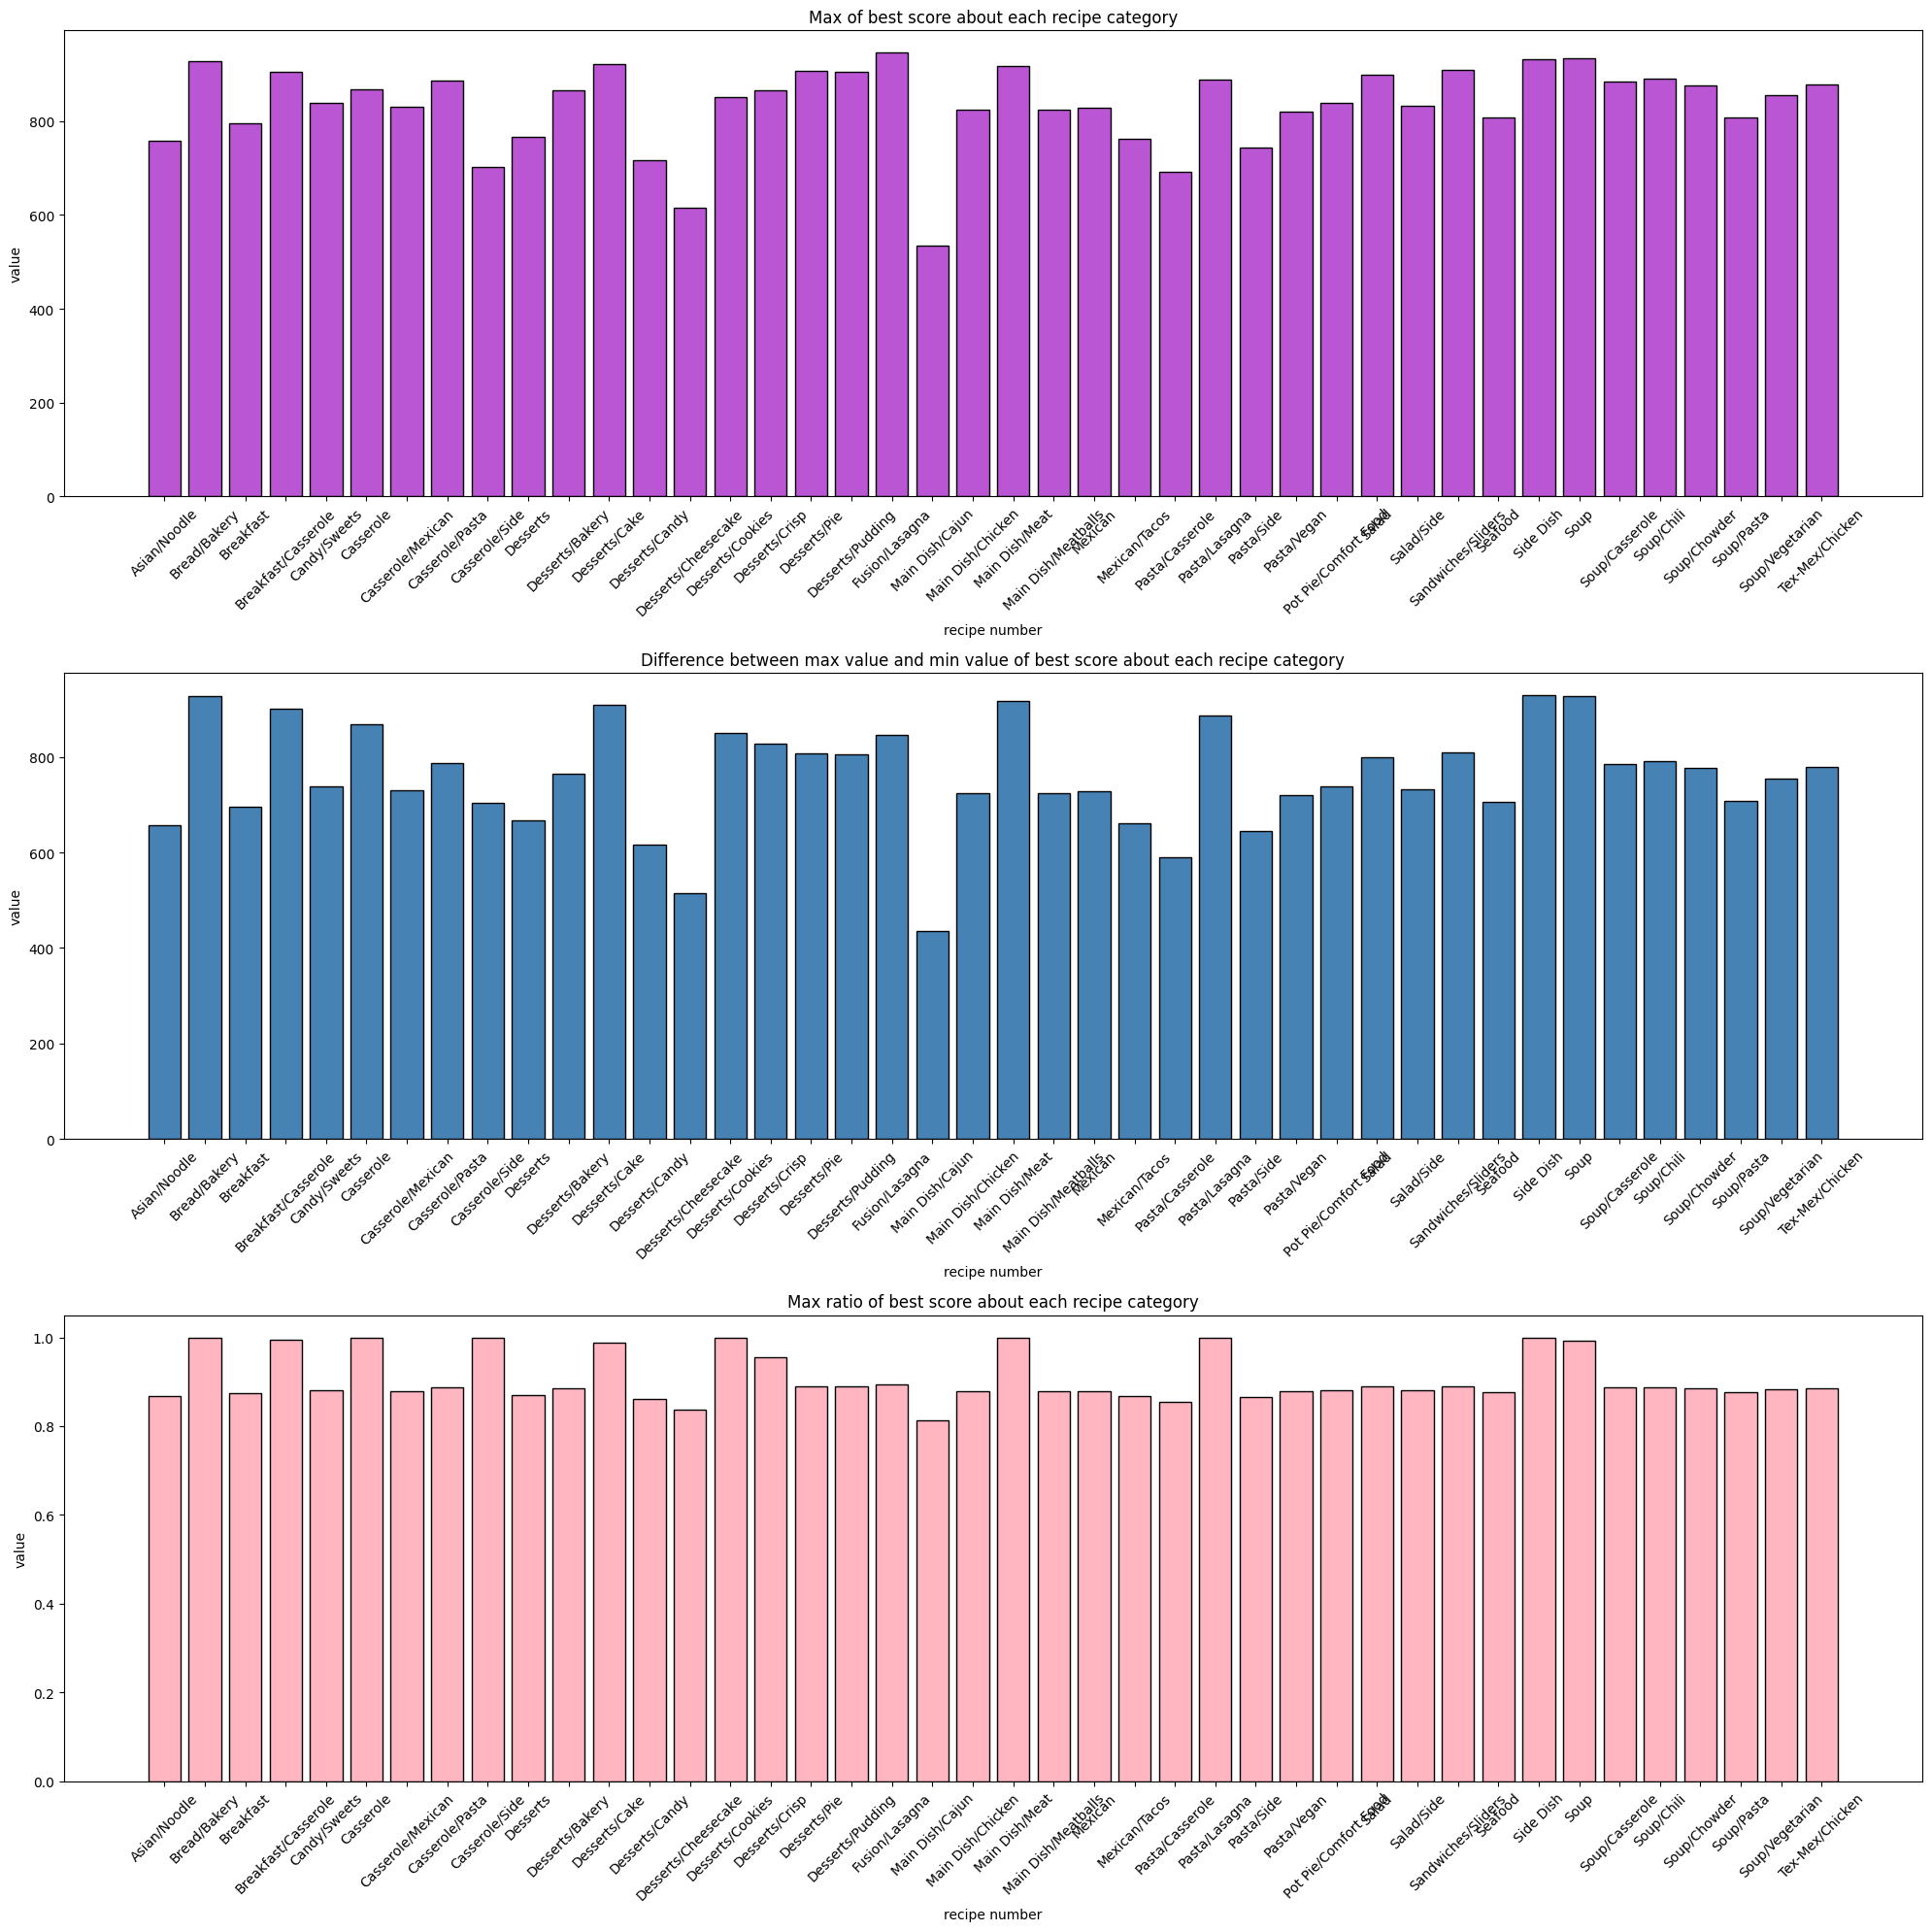

In [242]:
ig, axs = plt.subplots(3, 1, figsize=(20, 20))
# plt.xticks(rotation=45)
# 첫 번째 그래프
axs[0].bar(reci2.food_category, reci2[('best_score', 'max')],
           color='#BA55D3', edgecolor='black')
axs[0].set_xticklabels(reci2.food_category, rotation=45)
axs[0].set_title('Max of best score about each recipe category')
axs[0].set_xlabel('recipe number')
axs[0].set_ylabel('value')

# 두 번째 그래프
# plt.xticks(rotation=45)
axs[1].bar(reci2.food_category, reci2.diff_score,
           color='#4682B4', edgecolor='black')
axs[1].set_xticklabels(reci2.food_category, rotation=45)
axs[1].set_title(
    'Difference between max value and min value of best score about each recipe category')
axs[1].set_xlabel('recipe number')
axs[1].set_ylabel('value')

# 세 번째 그래프
plt.xticks(rotation=45)
axs[2].bar(reci2.food_category, reci2.diff_ratio,
           color='#FFB6C1', edgecolor='black')
axs[2].set_xticklabels(reci2.food_category, rotation=45)
axs[2].set_title('Max ratio of best score about each recipe category')
axs[2].set_xlabel('recipe number')
axs[2].set_ylabel('value')

# 그래프 간격 자동 조정
plt.tight_layout()

# 그래프 출력
plt.show()

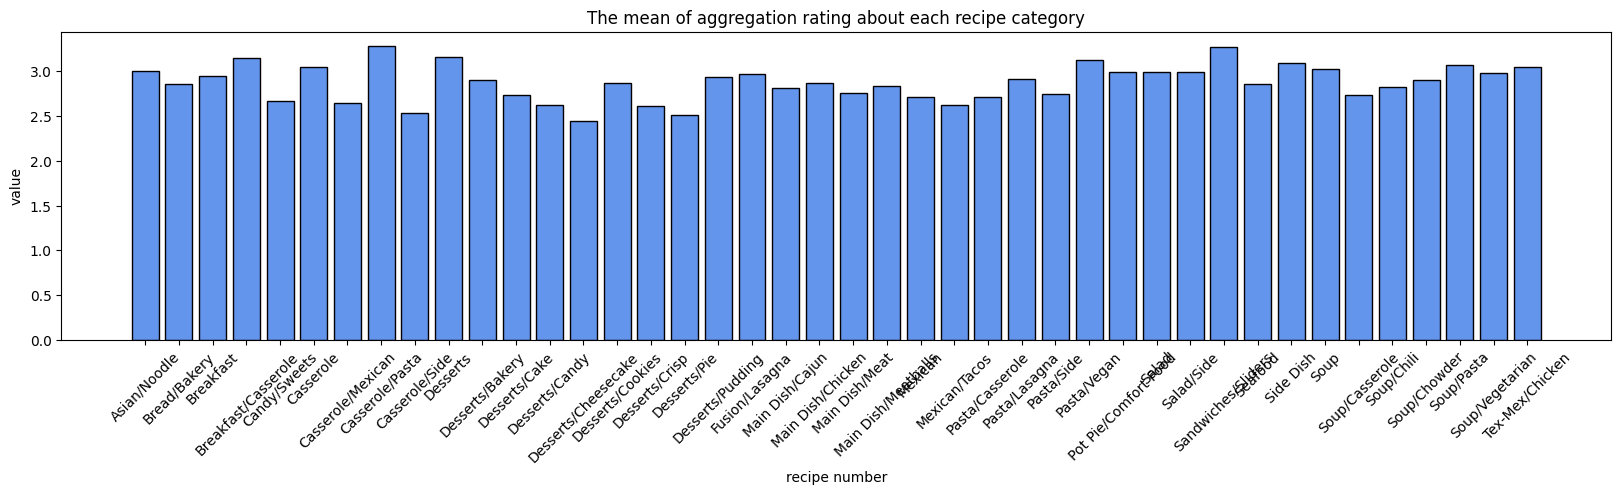

In [243]:
# 그래프 크기 설정
plt.figure(figsize=(20, 4))

# 수직 막대그래프
plt.bar(reci2.food_category, reci2[(('agg_rating', 'mean'))],
        color='#6495ED', edgecolor='black')
plt.xticks(rotation=45)
plt.title('The mean of aggregation rating about each recipe category')
plt.xlabel('recipe number')
plt.ylabel('value')
plt.show()


In [260]:
def dvid_star_score(col):
    if col <= 1:
        return 'low'
    elif (col >=2)&(col<=4):
        return 'medium'
    elif col>=5:
        return 'high'

In [261]:
df['new_star'] = df.stars.apply(lambda x: dvid_star_score(x))

In [268]:
summary = df.groupby(['food_category', 'new_star'])[['created_at']].count().reset_index()


In [275]:
summary1 = summary.pivot(index='food_category', columns='new_star',
                         values='created_at').fillna(0)


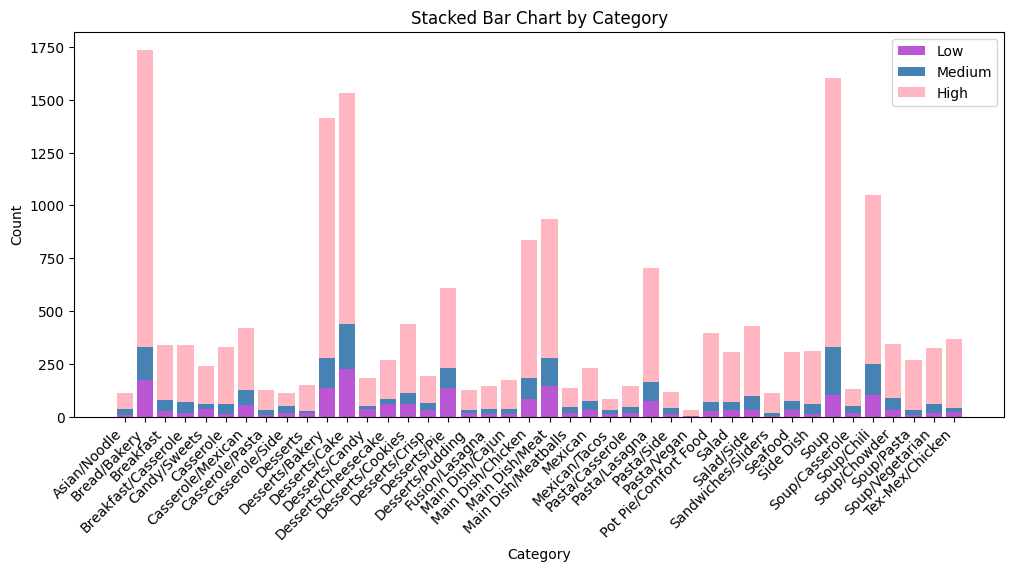

In [285]:
# x축 카테고리 설정
categories = summary1.index  # ['chinese', 'italian', 'mexican']
x = np.arange(len(categories))  # x축 인덱스
width = 0.2  # 막대 너비


fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(categories, summary1['low'], label='Low', color='#BA55D3')
ax.bar(categories, summary1['medium'],
       bottom=summary1['low'], label='Medium', color='#4682B4')
ax.bar(categories, summary1['high'], bottom=summary1['low'] +
       summary1['medium'], label='High', color='#FFB6C1')

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right")

ax.set_ylabel('Count')
ax.set_xlabel('Category')
ax.set_title('Stacked Bar Chart by Category')
ax.legend()

plt.show()




In [244]:
# 하나의 유저가 여러개 리뷰를 쓴게 있는지 확인

In [194]:
df.loc[(df.freq_reaction > 1) & (df.user_name == 'ahmom')]


,Column1,recipe_number,recipe_code,recipe_name,comment_id,user_id,user_name,user_reputation,created_at,reply_count,...,best_score,text,freq_reaction,adj_reput,like_ratio,new_best_score,new_like_ratio,agg_rating,food_category,feature
28,27,1,14299,Creamy White Chili,sp_aUSaElGf_14299_c_432496,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622648873,0,...,329,EXCELLENT RECIPE!! This will be on regular rot...,11,0.090909,0.8,1.738901,4.095238,4.166828,Soup/Chili,"#creamy, #white, #chili, #hearty"
766,108,2,3309,Best Ever Banana Bread,sp_aUSaElGf_3309_c_331695,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622718003,0,...,100,This turned out wonderfully. I used bananas th...,11,0.090909,0.0,0.528541,0.000000,3.105708,Bread/Bakery,"#banana, #bread, #classic, #homemade"
3954,94,10,2912,Zucchini Pizza Casserole,sp_aUSaElGf_2912_c_359273,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622718144,0,...,100,Very tasty!! To those who thought it was too s...,11,0.090909,0.0,0.528541,0.000000,2.505708,Casserole,"#zucchini, #pizza, #casserole, #fusion"
4774,302,12,19731,Cauliflower Soup,sp_aUSaElGf_19731_c_139670,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622717031,0,...,100,excellent!,11,0.090909,0.0,0.528541,0.000000,3.105708,Soup/Vegetarian,"#cauliflower, #soup, #vegetarian, #healthy"
6369,162,18,2872,Stuffed Pepper Soup,sp_aUSaElGf_2872_c_185471,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622717251,0,...,100,I LOVE this soup!!,11,0.090909,0.0,0.528541,0.000000,3.105708,Soup,"#stuffedpepper, #soup, #hearty, #vegetable"
6406,201,18,2872,Stuffed Pepper Soup,sp_aUSaElGf_2872_c_139758,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622717031,0,...,100,EXCELLENT!,11,0.090909,0.0,0.528541,0.000000,3.105708,Soup,"#stuffedpepper, #soup, #hearty, #vegetable"
7699,87,25,23222,Baked Mushroom Chicken,sp_aUSaElGf_23222_c_356984,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622718079,0,...,100,VERY good,11,0.090909,0.0,0.528541,0.000000,3.105708,Main Dish/Chicken,"#baked, #mushroom, #chicken, #savory"
11088,90,45,41384,Black Bean ‘n’ Pumpkin Chili,sp_aUSaElGf_41384_c_224685,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622717432,0,...,100,It just tasted funny to me.,11,0.090909,0.0,0.528541,0.000000,1.305708,Soup/Chili,"#blackbean, #pumpkin, #chili, #vegetarian"
11331,6,47,15805,Bruschetta Chicken,sp_aUSaElGf_15805_c_354845,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622718080,0,...,100,Very good!!,11,0.090909,0.0,0.528541,0.000000,2.505708,Main Dish/Chicken,"#bruschetta, #chicken, #Italian, #flavorful"
12926,46,58,32248,Smothered Chicken Breasts,sp_aUSaElGf_32248_c_261981,u_1oKVZT7bnHOk8MH7Aom0wkTCJNo,ahmom,1,1622717612,0,...,100,OHHH so good!,11,0.090909,0.0,0.528541,0.000000,3.105708,Main Dish/Chicken,"#smothered, #chickenbreasts, #hearty, #comfort"


In [249]:
df = df.drop(columns=['Column1'])


In [254]:
df = df.reset_index()

In [257]:
from sqlalchemy import create_engine
import pandas as pd

# PostgreSQL 연결 정보 설정
DATABASE_URL = "postgresql://user:pass@my_postgres:5432/mydb"

# SQLAlchemy 엔진 생성
engine = create_engine(DATABASE_URL)

df.to_sql('new_review', engine, if_exists='append', index=False)


In [ ]:
# LLM

In [26]:
import os

os.environ["key"] = ""


In [ ]:
from langchain.prompts import PromptTemplate
from langchain.llms import OpenAI
from langchain.schema import StrOutputParser

# import LLM 
llm = OpenAI(openai_api_key='', temperature=0.7)

# prompt1 : categorizing recipe into some categories
prompt1 = PromptTemplate.from_template("""
                                        You're expert of recipe.
                                        Please categorize {recipe_name} into some categries such as Mexican, desert, Italian etc.
                                        """)

# prompt2 : generate tags about each recipe name
prompt2 = PromptTemplate.from_template(
    """
    You're expert of recipe.
    Please extract potential keyword from {recipe_name} in type of tags.
    """)

# parser
output_parser = StrOutputParser()

# ✅ conect each step with pipe
chain = (
    prompt1 | llm | output_parser |
    prompt2 | llm | output_parser
)

# execute
result = chain.invoke({"topic": "black holes"})
print(result)
